**Obrada informacija**: Prva laboratorijska vježba

Rijeke imaju veliki gospodarski značaj, od termoelektrana i nuklearnih elektrana kojima su rijeke nužne za rad, javne vodoopskrbe do poljoprivrede i transporta. Premda ljudi danas uvelike upravljaju vodotocima, uslijed vremenskih prilika ipak može doći do poplava, erozija tla i sličnih prirodnih nepogoda. Kako bismo se mogli na vrijeme pripremiti za potencijalne probleme, potrebno je istražiti ponašanje rijeka na temelju višegodišnjih praćenja vodostaja. U ovoj laboratorijskoj vježbi ćete analizirati vodostaje rijeke Save kroz period od 25 godina.

Unutar komprimiranog direktorija u kojem se nalazi ova bilježnica, nalazi se i .mat datoteka s podacima o vodostaju rijeke Save u periodu od 1.1.1982. do 31.12.2007. Svaki podatak označava jedan dan mjerenja vodostaja.

Vježba se izvodi u Pythonu/Google Colabu, a sve naredbe potrebne za provedbu vježbe te njihova objašnjenja dana su u predavanju. Ova laboratorijska vježba nosi 3 boda.

Kad ste gotovi s vježbom, na *Moodle* postavite .pdf izvješće s vježbe (.pdf izvješće možete generirati s naredbom File-Print-Location: PDF).

**1.**	Učitajte biblioteke: NumPy, matplotlib.pyplot, scipy.fft, signal iz scipy te pywt.

In [ ]:
# Ovo je mjesto na kojem možete izvoditi svoj kod.
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
from scipy import signal
import pywt

**2.**	Učitajte podatke o vodostaju iz .mat datoteke koja se nalazi unutar istog komprimiranog direktorija. Učitani podaci su spremljeni u rječnik. Izdvojite ključ i pripadne podatke o vodostajima te po potrebi smanjite dimenziju.

Savjet: .mat datoteku učitajte sa svog Google Drivea (unutar mape Colab Notebooks na svom Google Driveu postavite .mat datoteku). Ostali savjeti nalaze se u sljedećem programskom odsječku.

In [ ]:
# Ovo je mjesto na kojem možete izvoditi svoj kod.

from google.colab import drive
drive.mount('/content/drive')

# Nakon što pokrenete ovaj odsječak koda, pojavit će se link u prozoru ispod. Kliknite na link, prijavite se sa svojim Google računom te ćete
# dobiti kod koji trebate kopirati u izlaz ispod ovog prozora (u prozor "Enter your authorization code: "). Nakon što upišete dobiveni kod,
# pojavit će se poruka "Mounted at /content/drive".
# Ako unutar takvog Colab Notebook direktorija imate spremljenu datoteku "OIkobas.mat", možete joj pristupiti sljedećim liniijama koda:
from scipy import io
kobas_iz_matlaba=io.loadmat("drive/My Drive/Colab Notebooks/3_OIkobas.mat")
print(kobas_iz_matlaba)

kobas_mjerenja = kobas_iz_matlaba['kobas'] # vrijednost ključa
kobas = np.squeeze(kobas_mjerenja) # smanjivanje dimenzije



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Sat Oct 10 13:46:29 2020', '__version__': '1.0', '__globals__': [], 'kobas': array([[661],
       [674],
       [685],
       ...,
       [242],
       [230],
       [228]], dtype=uint16)}


**3.**	Ispišite: broj dana za koje postoje podaci o vodostajima, srednju vrijednost vodostaja, standardnu devijaciju, minimalnu vrijednost, maksimalnu vrijednost te median.

In [ ]:
# Ovo je mjesto na kojem možete izvoditi svoj kod.
broj_dana = kobas.size
print("Broj dana za koje postoji vodostaj iznosi: %d" % broj_dana)

srednja_vrijednost = np.mean(kobas)
print("Standardna vrijednost vodostaja iznosi: %f" % srednja_vrijednost)

standard_dev = np.std(kobas)
print("Standardna devijacija iznosi: %f" % standard_dev)

min = np.min(kobas)
print("Minimalna vrijednost iznosi: %d" % min)

max = np.max(kobas)
print("Maksimalna vrijednost iznosi: %d" % max)

median = np.median(kobas)
print("Median iznosi: %d" % median)



Broj dana za koje postoji vodostaj iznosi: 9496
Standardna vrijednost vodostaja iznosi: 294.257582
Standardna devijacija iznosi: 183.091672
Minimalna vrijednost iznosi: 17
Maksimalna vrijednost iznosi: 878
Median iznosi: 255


**4.** Nacrtajte vodostaj. Obilježite x i y os te naslov slike.

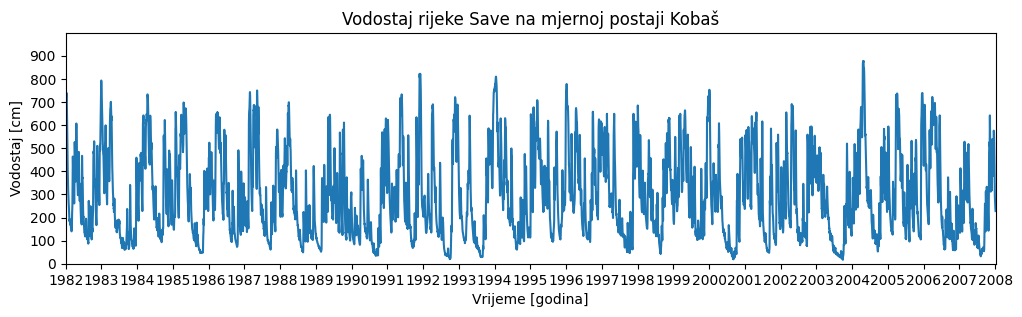

In [ ]:
# Ovo je mjesto na kojem možete izvoditi svoj kod.
plt.figure(figsize =(12,3))
plt.title('Vodostaj rijeke Save na mjernoj postaji Kobaš')
plt.xlabel("Vrijeme [godina]")
plt.ylabel("Vodostaj [cm]")
plt.xticks(np.arange(0, kobas.size, 365), np.arange(1982, 2009, 1))
plt.xlim(0, kobas.size)
plt.ylim(0, 1000)
plt.yticks(np.arange(0,1000,100))
plt.plot(np.arange(0,broj_dana,1), kobas)
plt.show()

**5.**	Izračunajte diskretnu Fourierovu transformaciju zadanog vodostaja. Ispišite dobivene vrijednosti. Nacrtajte apsolutnu vrijednost dobivenih koeficijenata.

Vrijednosti DFT: 
[2794270.            -0.j           -9312.52756202+49784.33987081j
   80617.82235263-75905.53826228j ...  -75144.8689581 -18406.78122837j
   80617.82235263+75905.53826228j   -9312.52756202-49784.33987081j]


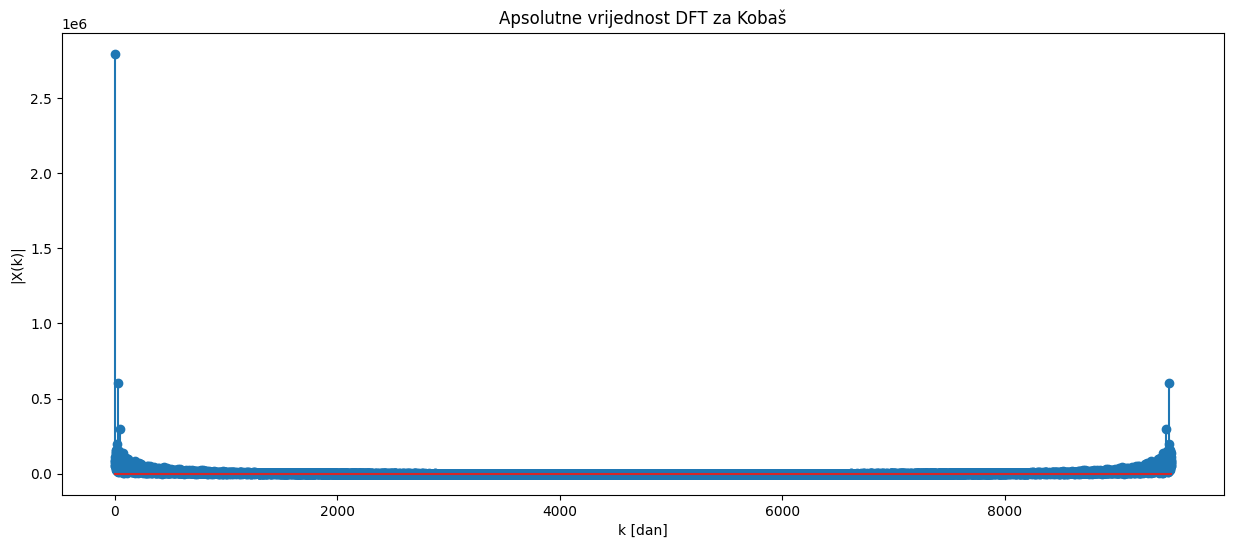

In [ ]:
# Ovo je mjesto na kojem možete izvoditi svoj kod.
x = np.array(kobas)
X = fft(kobas, kobas.size)
print("Vrijednosti DFT: ")
print(X)

plt.figure(figsize = (15,6))
plt.title('Apsolutne vrijednost DFT za Kobaš')
plt.stem(abs(X))
plt.xlabel('k [dan]')
plt.ylabel('|X(k)|')
plt.xticks(np.arange(0,kobas.size,2000))
plt.show()


**6.**	Izračunajte Fourierovu transformaciju na vremenskom otvoru zadanog vodostaja koristeći pravokutni otvor širine 2 godine. Prikažite rezultat pomoću pcolormesh. Odgovorite: koje frekvencije su vidljive u vodostaju? Koje godine se javljaju?

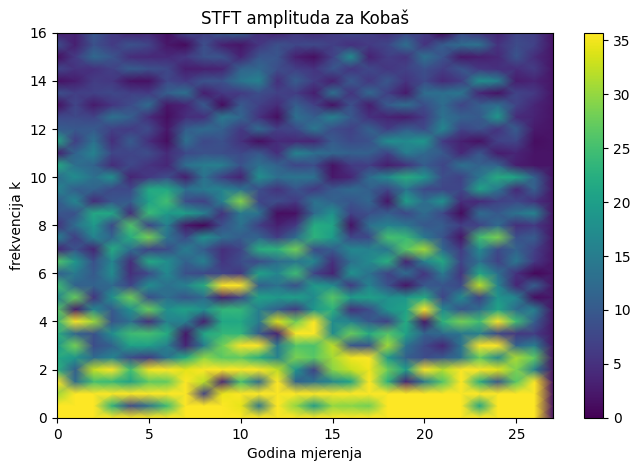

In [ ]:
# Ovo je mjesto na kojem možete izvoditi svoj kod.
T = 365
fs = 365
window = 'boxcar'
f, t, Zxx = signal.stft(x, fs, window, nperseg = 2*T)
plt.figure(figsize = (8,5))
plt.pcolormesh(t, f, np.abs(Zxx), vmin=0, vmax=np.abs(Zxx.max())/10, shading='gouraud')
plt.colorbar()
plt.title('STFT amplituda za Kobaš')
plt.ylabel('frekvencija k')
plt.ylim(0, 16)
plt.yticks(np.arange(0, 17, 2))
plt.xlabel('Godina mjerenja')
plt.show()


:ODGOVOR: *Ovo je mjesto za odgovor na pitanja iz 6. zadatka.*
Uočljive su frekvencije k=1 koja predstavlja jednu godinu, k=2 koja predstavlja pola godine, k=4 koja predstavlja 3 mjeseca i k=12 koja predstavlja jedan mjesec. Time se na grafu pokazuje koliko je pri određenoj frekvenciji razina vodostaja gdje žuće predstavlja veću razinu vodostaja (amplitudu). Kod frekvencije k=1 koja predstavlja amplitudu u frekvencije jedne godine uviđamo da je manja amplituda oko 1990. (8.godina mjerenja) u kojima se zna da je bila suša. Također veću količinu žutog odnosno većeg vodostaja uočavamo oko 12. godine mjerenja odnosno 1994. godine koja je bila vlažna godina. Ostala područja ne možemo pretežito razlikovati jer su slične amplitude (boje) što je upravo i mana korištenja STFT s fiksnim okvirom.

**7.**	Upotrijebite drugu širinu otvora (po izboru) i ponovite prethodni zadatak. Ispišite koju širinu ste upotrijebili. Objasnite razlike u dobivenim slikama.

Upotrebljena širina: 182.5


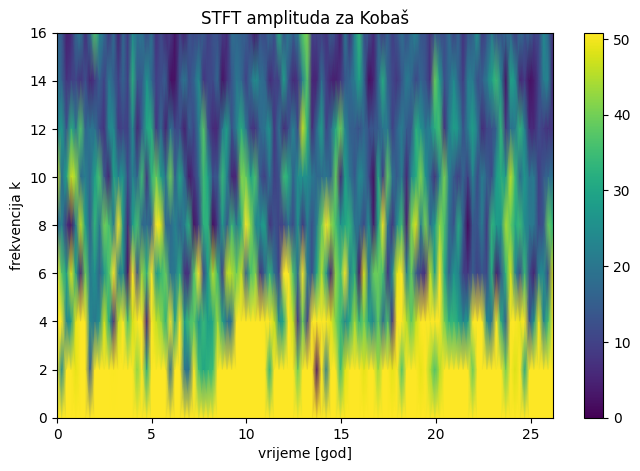

In [ ]:
# Ovo je mjesto na kojem možete izvoditi svoj kod.

print("Upotrebljena širina: %.1f" % (T/2))

f, t, Zxx = signal.stft(x, fs, window, nperseg = T/2)
plt.figure(figsize = (8,5))
plt.pcolormesh(t, f, np.abs(Zxx), vmin=0, vmax=np.abs(Zxx.max())/10, shading='gouraud')
plt.colorbar()
plt.title('STFT amplituda za Kobaš')
plt.ylabel('frekvencija k')
plt.ylim(0, 16)
plt.yticks(np.arange(0, 17, 2))
plt.xlabel('vrijeme [god]')
plt.show()



ODGOVOR: *Ovo je mjesto za odgovor na pitanje iz 7. zadatka.* Kako sam odabrao manji period (T = 182) tako je i manja veličina otvora te je zbog toga graf "slijep" na niske frekvencije odnosno jako teško je razlikovati blisko raspoređene frekvencijske komponente koje predstavljaju razliku vodostaju između bliskih vremena no zbog toga možemo uočiti brze promjene signala tijekom vremena.

**8.**	Ispišite sve obitelji kontinuiranih valića koje se nalaze u PyWavelets biblioteci. Na istoj slici, koristeći subplot naredbu, nacrtajte dvije valićne funkcije po izboru. U naslovu svake slike napišite o kojim valićima se radi.

Obitelji kontinuiranih valića su: 
['cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'mexh', 'morl', 'shan']


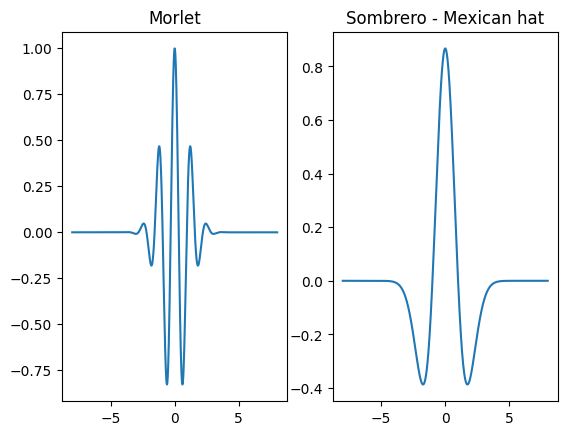

In [ ]:
# Ovo je mjesto na kojem možete izvoditi svoj kod.
print("Obitelji kontinuiranih valića su: ")
print(pywt.wavelist(kind='continuous'))

plt.figure(1)

plt.subplot(1,2,1)
valic = 'morl'
w = pywt.ContinuousWavelet(valic)
psi, t = w.wavefun(level = 10)
plt.plot(t, psi)
plt.title('Morlet')

plt.subplot(1,2,2)
valic = 'mexh'
w = pywt.ContinuousWavelet(valic)
psi, t = w.wavefun(level = 10)
plt.plot(t, psi)
plt.title('Sombrero - Mexican hat')


plt.show()



**9.**	Koristeći Morlet valić, odredite kontinuiranu valićnu transformaciju zadanog vodostaja. Nacrtajte apsolutnu vrijednost dobivenih koeficijenata. Odgovorite: koje frekvencije su vidljive u vodostaju? Koje godine se javljaju?

<Figure size 640x480 with 0 Axes>

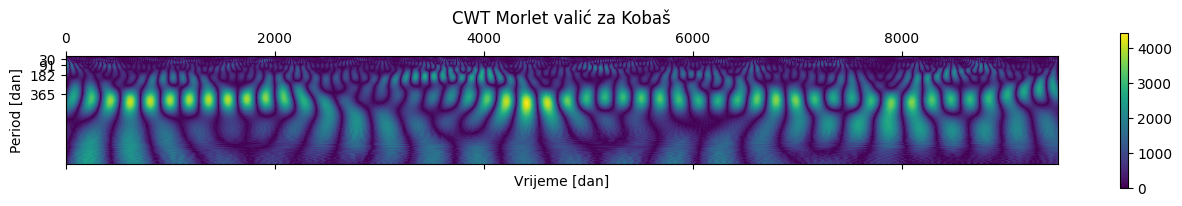

In [ ]:
# Ovo je mjesto na kojem možete izvoditi svoj kod.
plt.figure(1)

valic = 'morl'
step = 0.7
skala = np.arange(0.1, 2 * T, step)

coef, fresq = pywt.cwt(x, skala, valic)

plt.matshow(abs(coef))

plt.yticks([T // 12, T // 4, T // 2, T])
plt.xticks(np.arange(0,8001,2000))
plt.ylabel('Period [dan]')
plt.xlabel('Vrijeme [dan]')
plt.title('CWT Morlet valić za Kobaš')

plt.colorbar()




:ODGOVOR: *Ovo je mjesto za odgovor na pitanja iz 9. zadatka.* Uočljive su frekvencije kod mjesec dana, 3 mjeseca, pola godine i godinu dana te čak i razdoblja od 2 godine jer je kod svake od tih frekvencija u nekim razdobljima u tom periodu mjerenja bila veća amplituda. Na to najviše utječu godišnja doba odnosno kišni ili sušni mjeseci/godine. Gledajući period od 365 dana odnosno godinu dana uočavamo najviše izraženu žutu boju kod 4250. dana odnosno 12. godina mjerenja od početka mjerenja 1982. čime dolazimo do već spomenutog povećanog vodostaja 1994. odnosno najvlažnije godine. Najplavija boja odnosno najmanji vodostaj javlja se oko 2600. dana mjerenja odnosno oko 7. godine mjerenja što predstavlja period sušnih godina koje su dogodile upravo oko 1989. godine. Povećani vodostaj se može i istaknuti oko 3. godine mjerenja time označavajući period oko 1985. godine koji je bio vlažniji od nekih kasnijih.

**10.**	Odgovorite: objasnite razliku u dobivenim rezultatima STFT i CWT.

STFT koristi prozore koji su fiksne duljine time onemogučavajući hvatanje brzih promjena koristeći veće prozore te nemogućnost razlikovanja blisko razmaknutih frekvencija odnosno lošiju frekvencijsku rezoluciju koristeći manje prozore. Dok CWT koriste valiće koje se puno bolje adaptiraju vremenskim i frekvencijskim karakteristikama i osigurava visoku vremensku rezoluciju za prolazne događaje i visokofrekventnu rezoluciju. To možemo uočiti kod grafa CWT gdje se točno mogu očitati čak i vlažniji mjeseci/godine odnosno brze promjene dok se kod STFT oni teško mogu uočiti zbog prozora fiksne duljine. Također je puno lakše prepoznati najvlažnije godine iako su one blisko razmaknute što je još jedan problem kod STFT.

ODGOVOR: *Ovo je mjesto za odgovor na pitanje iz 10. zadatka.*